# Customer Lifetime Value Prediction

**Project Type:** Marketing Analytics | Digital Analytics | Data Science | Predictive Analytics

This project predicts customer 12-month future CLV using ecommerce, web analytics, engagement, acquisition, and retention features.

## Business Objective

Identify which customers are likely to generate the highest future value so that marketing and CRM teams can optimize retention, personalization, acquisition quality, and budget allocation.


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', None)


## 1. Load Data


In [18]:
customers = pd.read_csv('../data/customer_clv_dataset.csv')
transactions = pd.read_csv('../data/transactions.csv')

print('Customer dataset:', customers.shape)
print('Transaction dataset:', transactions.shape)
customers.head()


Customer dataset: (8000, 22)
Transaction dataset: (49776, 7)


,customer_id,customer_segment_seed,country,primary_device,acquisition_channel,acquisition_date,tenure_days,recency_days,frequency_12m,avg_order_value_gbp,historical_revenue_12m_gbp,gross_margin_rate,historical_margin_12m_gbp,discount_usage_rate,return_rate,sessions_90d,product_views_90d,cart_additions_90d,email_open_rate,support_tickets_12m,churn_risk_score,future_clv_12m_gbp
0,CUST-100000,High Value Loyal,Netherlands,Mobile,Organic Search,2024-11-07,257,25,10,120.62,1416.20,0.446,477.22,0.244,0.244,21,91,10,0.544,0,0.171,295.55
1,CUST-100001,At Risk,United States,Desktop,Organic Search,2024-04-10,564,107,5,55.76,298.14,0.285,24.66,0.417,0.709,1,5,0,0.114,2,0.673,16.59
2,CUST-100002,High Value Loyal,India,Mobile,Organic Search,2024-09-18,310,24,13,114.14,1498.56,0.460,526.64,0.156,0.235,22,119,9,0.976,0,0.381,150.67
3,CUST-100003,High Value Loyal,United Kingdom,Tablet,Organic Search,2024-08-01,652,24,13,106.55,1171.91,0.450,429.18,0.157,0.185,23,89,19,0.685,1,0.357,451.93
4,CUST-100004,New Customers,United Kingdom,Mobile,Paid Search,2024-04-15,41,55,4,27.59,85.79,0.356,27.32,0.622,0.106,10,72,3,0.127,0,0.258,17.57


## 2. Exploratory Data Analysis


In [19]:
customers.describe().T


,count,mean,std,min,25%,50%,75%,max
tenure_days,8000.0,294.588375,196.851062,1.000,106.00000,283.000,448.0000,729.000
recency_days,8000.0,53.621875,29.455222,1.000,32.00000,49.000,70.2500,244.000
frequency_12m,8000.0,6.222000,3.924652,1.000,3.00000,5.000,8.0000,24.000
avg_order_value_gbp,8000.0,60.437591,23.900427,8.000,43.36000,56.500,74.1925,159.520
historical_revenue_12m_gbp,8000.0,431.111256,421.805234,7.530,138.46750,296.435,552.3000,3228.110
gross_margin_rate,8000.0,0.350974,0.072791,0.120,0.29800,0.349,0.4010,0.634
historical_margin_12m_gbp,8000.0,129.616294,155.436780,1.330,31.82000,71.245,155.2100,1207.950
discount_usage_rate,8000.0,0.482496,0.233163,0.006,0.30000,0.461,0.6590,0.996
return_rate,8000.0,0.238049,0.143744,0.001,0.12700,0.215,0.3250,0.750
sessions_90d,8000.0,12.334000,6.796247,1.000,7.00000,12.000,17.0000,39.000


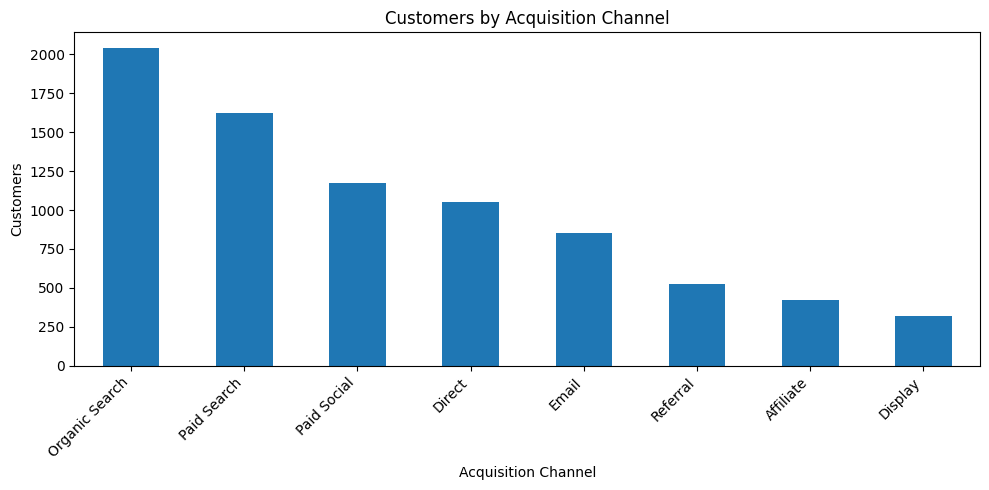

In [20]:
customers['acquisition_channel'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title('Customers by Acquisition Channel')
plt.xlabel('Acquisition Channel')
plt.ylabel('Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


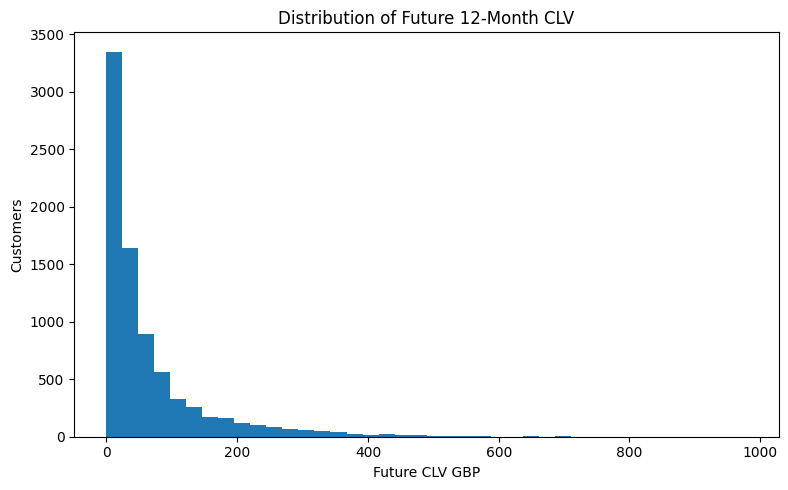

In [21]:
customers['future_clv_12m_gbp'].plot(kind='hist', bins=40, figsize=(8,5))
plt.title('Distribution of Future 12-Month CLV')
plt.xlabel('Future CLV GBP')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()


## 3. Feature Selection

The target variable is `future_clv_12m_gbp`. The synthetic seed segment is excluded because it is only used to generate realistic behavioural patterns.


In [22]:
features = [
    'country', 'primary_device', 'acquisition_channel',
    'tenure_days', 'recency_days', 'frequency_12m', 'avg_order_value_gbp',
    'historical_revenue_12m_gbp', 'gross_margin_rate', 'historical_margin_12m_gbp',
    'discount_usage_rate', 'return_rate', 'sessions_90d', 'product_views_90d',
    'cart_additions_90d', 'email_open_rate', 'support_tickets_12m', 'churn_risk_score'
]

target = 'future_clv_12m_gbp'

X = customers[features]
y = customers[target]

X.head()


,country,primary_device,acquisition_channel,tenure_days,recency_days,frequency_12m,avg_order_value_gbp,historical_revenue_12m_gbp,gross_margin_rate,historical_margin_12m_gbp,discount_usage_rate,return_rate,sessions_90d,product_views_90d,cart_additions_90d,email_open_rate,support_tickets_12m,churn_risk_score
0,Netherlands,Mobile,Organic Search,257,25,10,120.62,1416.20,0.446,477.22,0.244,0.244,21,91,10,0.544,0,0.171
1,United States,Desktop,Organic Search,564,107,5,55.76,298.14,0.285,24.66,0.417,0.709,1,5,0,0.114,2,0.673
2,India,Mobile,Organic Search,310,24,13,114.14,1498.56,0.460,526.64,0.156,0.235,22,119,9,0.976,0,0.381
3,United Kingdom,Tablet,Organic Search,652,24,13,106.55,1171.91,0.450,429.18,0.157,0.185,23,89,19,0.685,1,0.357
4,United Kingdom,Mobile,Paid Search,41,55,4,27.59,85.79,0.356,27.32,0.622,0.106,10,72,3,0.127,0,0.258


## 4. Build Machine Learning Pipeline

The pipeline handles categorical variables using one-hot encoding and trains a Random Forest Regressor for CLV prediction.


In [23]:
categorical = ['country', 'primary_device', 'acquisition_channel']
numeric = [c for c in features if c not in categorical]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical),
        ('num', 'passthrough', numeric)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=120,
        random_state=42,
        max_depth=12,
        min_samples_leaf=8,
        n_jobs=-1
    ))
])


## 5. Train/Test Split and Model Training


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

model.fit(X_train, y_train)
predictions = model.predict(X_test)

print('Training rows:', X_train.shape[0])
print('Test rows:', X_test.shape[0])


Training rows: 6000
Test rows: 2000


## 6. Model Evaluation


In [25]:
mae = mean_absolute_error(y_test, predictions)
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print(f'MAE: £{mae:,.2f}')
print(f'RMSE: £{rmse:,.2f}')
print(f'R²: {r2:.4f}')


MAE: £28.05
RMSE: £47.26
R²: 0.6863


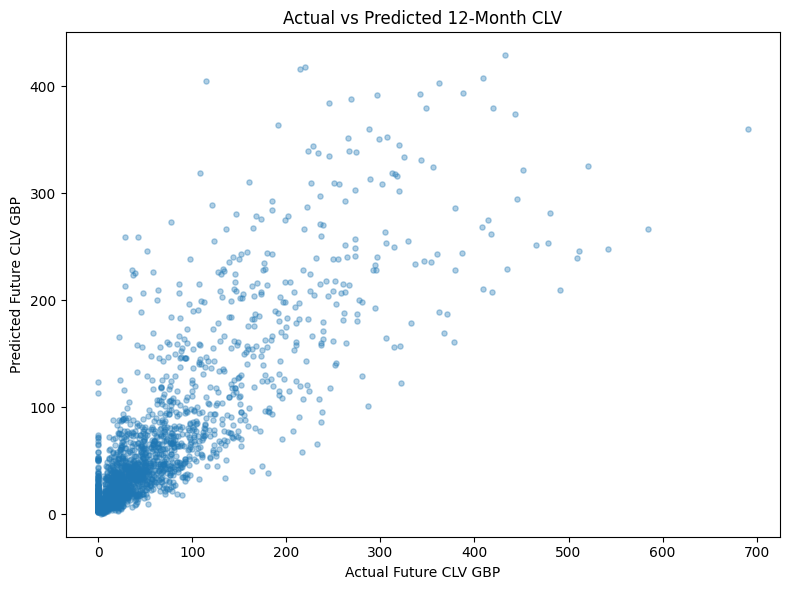

In [26]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, predictions, alpha=0.35, s=14)
plt.title('Actual vs Predicted 12-Month CLV')
plt.xlabel('Actual Future CLV GBP')
plt.ylabel('Predicted Future CLV GBP')
plt.tight_layout()
plt.show()


## 7. Predict CLV for All Customers


In [27]:
customers['predicted_clv_12m_gbp'] = model.predict(X).round(2)
customers['clv_tier'] = pd.qcut(
    customers['predicted_clv_12m_gbp'],
    q=4,
    labels=['Low CLV', 'Medium CLV', 'High CLV', 'Top CLV']
)

customers[['customer_id', 'predicted_clv_12m_gbp', 'clv_tier']].head()


,customer_id,predicted_clv_12m_gbp,clv_tier
0,CUST-100000,228.39,Top CLV
1,CUST-100001,13.05,Low CLV
2,CUST-100002,210.60,Top CLV
3,CUST-100003,263.20,Top CLV
4,CUST-100004,14.87,Low CLV


## 8. CLV Tier Profiling


In [28]:
tier_summary = customers.groupby('clv_tier', observed=False).agg(
    customers=('customer_id', 'count'),
    avg_predicted_clv_gbp=('predicted_clv_12m_gbp', 'mean'),
    avg_actual_future_clv_gbp=('future_clv_12m_gbp', 'mean'),
    avg_frequency_12m=('frequency_12m', 'mean'),
    avg_order_value_gbp=('avg_order_value_gbp', 'mean'),
    avg_recency_days=('recency_days', 'mean'),
    avg_churn_risk=('churn_risk_score', 'mean'),
    avg_discount_usage=('discount_usage_rate', 'mean')
).round(2).reset_index()

tier_summary


,clv_tier,customers,avg_predicted_clv_gbp,avg_actual_future_clv_gbp,avg_frequency_12m,avg_order_value_gbp,avg_recency_days,avg_churn_risk,avg_discount_usage
0,Low CLV,2000,9.65,8.16,2.54,39.98,65.26,0.59,0.49
1,Medium CLV,2000,26.13,24.36,4.63,50.28,58.06,0.47,0.56
2,High CLV,2000,52.24,52.53,6.80,62.82,49.69,0.37,0.57
3,Top CLV,2000,168.02,170.08,10.92,88.67,41.47,0.25,0.31


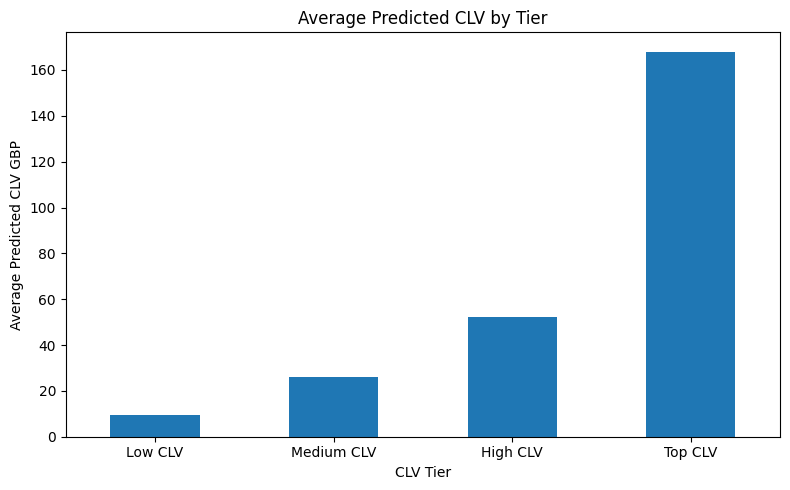

In [29]:
tier_summary.plot(x='clv_tier', y='avg_predicted_clv_gbp', kind='bar', figsize=(8,5), legend=False)
plt.title('Average Predicted CLV by Tier')
plt.xlabel('CLV Tier')
plt.ylabel('Average Predicted CLV GBP')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 9. Feature Importance


In [30]:
rf = model.named_steps['model']
ohe = model.named_steps['preprocessor'].named_transformers_['cat']
cat_names = list(ohe.get_feature_names_out(categorical))
feature_names = cat_names + numeric

feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

feature_importance.head(15)


,feature,importance
25,historical_margin_12m_gbp,0.861544
22,avg_order_value_gbp,0.013378
31,email_open_rate,0.013118
19,tenure_days,0.012672
23,historical_revenue_12m_gbp,0.011328
24,gross_margin_rate,0.011188
26,discount_usage_rate,0.010639
20,recency_days,0.010108
27,return_rate,0.009509
33,churn_risk_score,0.009367


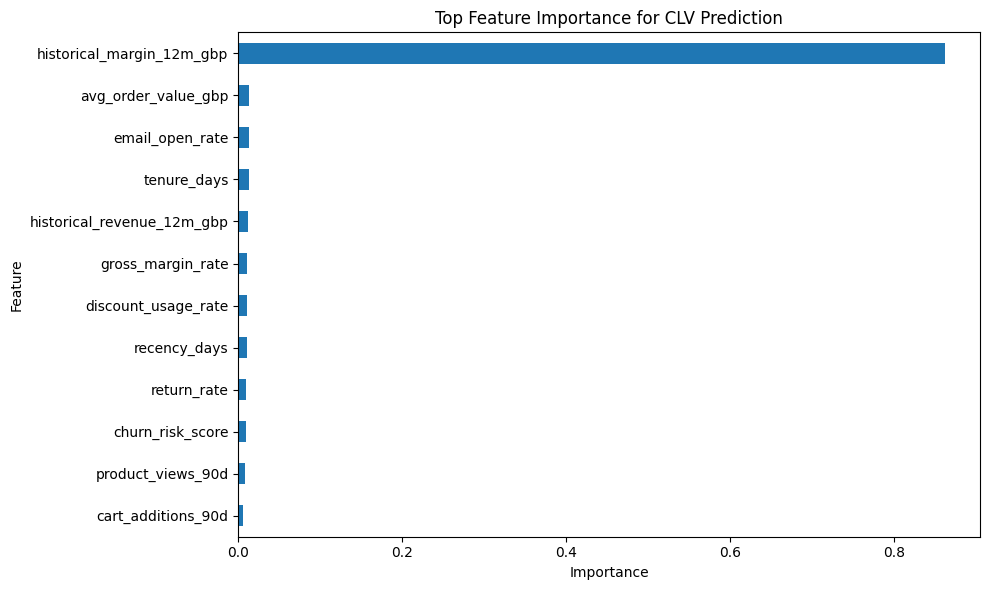

In [31]:
feature_importance.head(12).sort_values('importance').plot(
    x='feature', y='importance', kind='barh', figsize=(10,6), legend=False
)
plt.title('Top Feature Importance for CLV Prediction')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## 10. Business Strategy by CLV Tier

### Top CLV Customers
- Highest predicted future value
- Strong retention priority
- Strategy: VIP loyalty rewards, premium recommendations, early access, personalized CRM journeys

### High CLV Customers
- Strong growth and repeat-purchase potential
- Strategy: cross-sell, bundles, product recommendations, membership incentives

### Medium CLV Customers
- Moderate value with room for growth
- Strategy: nurture campaigns, basket recovery, targeted offers, content personalization

### Low CLV Customers
- Lower future value or higher churn risk
- Strategy: low-cost automation, suppress expensive paid retargeting, test win-back only where margin-positive

## Marketing Analytics Use Cases

- Improve customer retention
- Prioritize CRM campaigns
- Build lookalike audiences from high-CLV customers
- Reduce wasted discounting
- Improve acquisition channel quality
- Support budget allocation by predicted customer value


## 11. Save Outputs


In [32]:
customers.to_csv('../reports/customer_clv_predictions_from_notebook.csv', index=False)
tier_summary.to_csv('../reports/clv_tier_summary_from_notebook.csv', index=False)
feature_importance.to_csv('../reports/feature_importance_from_notebook.csv', index=False)

print('Outputs saved successfully.')


Outputs saved successfully.
